# Introduction

After identifying Gradient Boosting as the best-performing model for predicting Standard Yield, a residual diagnostic analysis was conducted to further evaluate the reliability of its predictions. While performance metrics such as RMSE and R² measure overall predictive accuracy, residual analysis helps determine whether the model's prediction errors are random, unbiased, and consistent across different observations and crop types.

# Objective

To evaluate the residuals of the final Gradient Boosting model and identify potential systematic errors, prediction bias, heteroscedasticity, unusual observations, and differences in prediction performance across crop types.

# Hypothesis

### Null Hypothesis (H₀):
The residuals of the Gradient Boosting model are randomly distributed around zero, show no significant heteroscedasticity, and do not exhibit substantial systematic differences across observations.

### Alternative Hypothesis (H₁):
The residuals exhibit systematic patterns, significant heteroscedasticity, prediction bias, or meaningful differences in model performance across observations or crop types.

In [1]:
cd ..

/home/dataflix/Projects/maji-ndogo-yield-intelligence


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

from src.preprocessing import ModelPreprocessors
from model_pipelines.ensemble_models import EnsembleStacking

2026-08-25 21:40:46 | src.data_ingestion | INFO | Starting data ingestion


In [ ]:
mp = ModelPreprocessors()
mp.prepare_data()
X_train, X_test, y_train, y_test = mp.X_y_train_test_split()

In [ ]:
# This parameters were established after conducting a random cross validation search during Gradient boosting experiment
gradient_params = {
    "n_estimators": 661,
    "learning_rate": 0.168307,
    "max_depth": 4,
    "min_samples_split": 18,
    "min_samples_leaf": 14,
    "subsample": 0.865009
}

In [ ]:
ensemble = EnsembleStacking()
ensemble.prepare_data()
ensemble.feature_transfromer()
gradient_pipeline = ensemble.gradient_boosting_pipeline(**gradient_params)

# Training GradientBoostingRegressor

In [6]:
def graddient_boot_model(X_train, X_test, y_train) -> tuple[GradientBoostingRegressor, np.ndarray]:
    fitted_model = gradient_pipeline.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)
    return fitted_model, y_pred

fitted_model, y_pred = graddient_boot_model(X_train, X_test, y_train)

## Metrics Evaluation

In [7]:
def metric_evaluation(y_test, y_pred)-> tuple[float, float]:
    rmse =root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

rmse, r2 = metric_evaluation(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"r2 score: {r2:.4f}")

RMSE: 0.0148
r2 score: 0.9836


# Residual diagnostic

### 1: residual vs predicted values

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

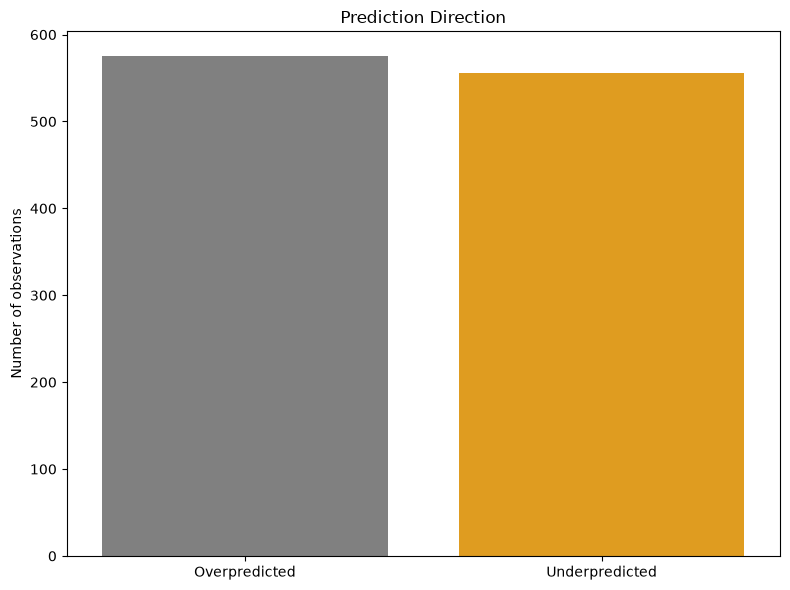

In [9]:
residuals = y_test -y_pred
residual_diff = residuals > 0
prediction_diff_count = residual_diff.value_counts()


plot_data = (
    prediction_diff_count.rename(index={
        True: "Underpredicted",
        False: "Overpredicted"
    }).rename("Count").reset_index().rename(columns={"Standard_yield": "Prediction"})
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=plot_data,
    x="Prediction",
    y="Count",
    hue="Prediction",
    palette={"Underpredicted": "orange", "Overpredicted": "grey"},
    legend=False
)

plt.title("Prediction Direction")
plt.xlabel("")
plt.ylabel("Number of observations")
plt.xticks()
plt.tight_layout()
plt.show()

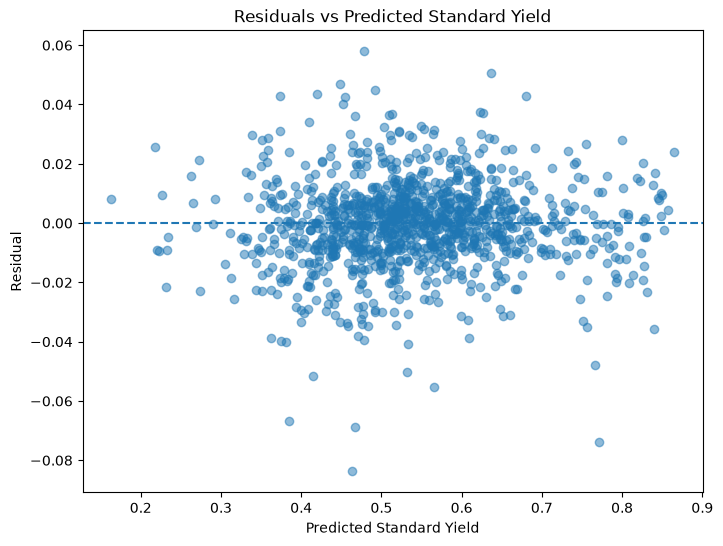

In [10]:
plt.figure(figsize =(8, 6))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.axhline(y = 0, linestyle = "--")
plt.xlabel("Predicted Standard Yield")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Standard Yield")

plt.show()


The model's errors are randomly distrbbuted around zero. It does not show strong curve or consistent bias. The gradient boosting model appears to capture the main relationship between features and standard yield

## 2: Check for Heteroscedasticity

In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

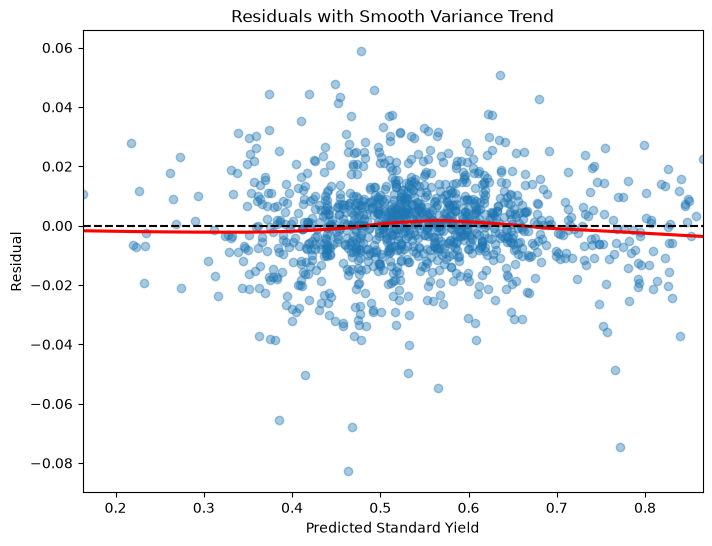

In [12]:
plt.figure(figsize=(8,6))
sns.residplot(x= y_pred, y = residuals, lowess=True, scatter_kws={"alpha":0.4}, line_kws={"color": "red"})
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Standard Yield")
plt.ylabel("Residual")
plt.title("Residuals with Smooth Variance Trend")
plt.show()


In [13]:
test_features = add_constant(np.asarray(y_pred))
bp_stat, bp_pvalue, _, f_pvalue = het_breuschpagan(residuals,test_features)

print(f"Breusch-Pagan p-value: {bp_pvalue:.4f}")
print(f"F-test p-value: {f_pvalue:.4f}")

Breusch-Pagan p-value: 0.0697
F-test p-value: 0.0698


The Breusch-Pagan test found no statistically significant heteroscedasticity at the 5% significance level, although the p-value suggests a possible weak variance pattern.

## 3: Distribution of residuals

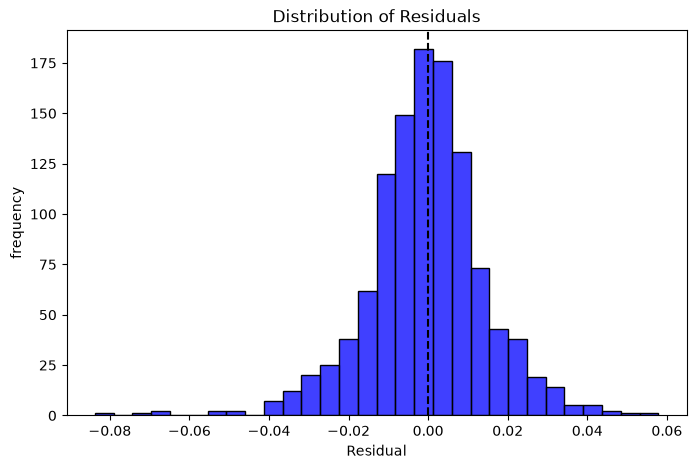

In [14]:
plt.figure(figsize = (8, 5))
sns.histplot(residuals, bins=30, color="blue")
plt.axvline(x=0, linestyle="--", color="black")
plt.xlabel("Residual")
plt.ylabel("frequency")
plt.title("Distribution of Residuals")
plt.show()

In [15]:
#Residual overal mean
round(float(residuals.mean()), 9)

-0.000480805

In [16]:
residuals.describe().T

count    1131.000000
mean       -0.000481
std         0.014776
min        -0.083776
25%        -0.008509
50%        -0.000207
75%         0.007523
max         0.057874
Name: Standard_yield, dtype: float64

The residuals are approximately bell-shaped and centere near zero suggesting the model has little overal bias; it does not consistently overpredict or underpredict. Most errors are smal, concentrated around 0 and generally withi about 0.02. The distribution is reasonably close to normal although a few observations in the tails maybe outliers. overall, this supports the model's adequacy.

## Q-Q Plot

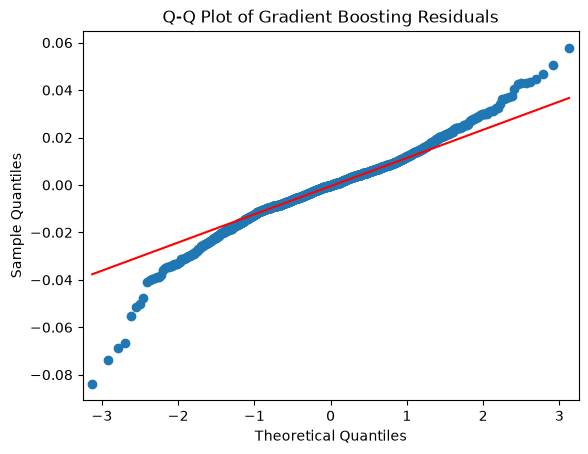

In [17]:
import statsmodels.api as sm 
sm.qqplot(residuals, line= "q")
plt.title("Q-Q Plot of Gradient Boosting Residuals")

plt.show()

The residuals are reasonably normal in the middle but not perfectly normal at the extremes. This is usually acceptable fro Gradient Boosting model since it does not require normally distributed residuals.

## A look at extreme errors

In [18]:
error_analysis = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "residual": residuals,
    "absolute_error": np.abs(residuals)
})

error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,actual,predicted,residual,absolute_error
2673,0.379822,0.463598,-0.083776,0.083776
1699,0.697544,0.771228,-0.073684,0.073684
5300,0.398811,0.467434,-0.068623,0.068623
4420,0.317976,0.384739,-0.066764,0.066764
1858,0.535914,0.478041,0.057874,0.057874
4405,0.510155,0.565348,-0.055193,0.055193
5447,0.362789,0.414401,-0.051612,0.051612
4923,0.686832,0.636122,0.050709,0.050709
3704,0.481716,0.531865,-0.050149,0.050149
4795,0.718024,0.765812,-0.047789,0.047789


In [22]:
worst_predictions = (
    X_test
    .join(
        error_analysis[["actual", "predicted", "residual", "absolute_error"]]
    )
    .sort_values("absolute_error", ascending=False)
)
display(worst_predictions.head(10))

,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Crop_type,actual,predicted,residual,absolute_error
2673,477.61730,-8.646999,-2.754283,Rural_Hawassa,22.357544,1264.9,-5.9,32.3,13.20,0.66,Silt,6.880999,0.039381,1.2,cassava,0.379822,0.463598,-0.083776,0.083776
1699,776.01105,-8.678539,-2.038050,Rural_Hawassa,4.942481,1684.6,-2.7,28.1,12.70,0.63,Volcanic,5.941209,0.075397,3.2,tea,0.697544,0.771228,-0.073684,0.073684
5300,518.87695,-11.012488,-9.479673,Rural_Akatsi,21.488810,1997.0,-4.8,31.9,13.55,0.71,Silt,5.464656,0.020986,0.5,cassava,0.398811,0.467434,-0.068623,0.068623
4420,836.67750,-6.529324,-8.204867,Rural_Amanzi,16.340954,1046.7,-2.7,31.5,14.40,0.62,Sandy,5.496467,0.140727,1.3,coffee,0.317976,0.384739,-0.066764,0.066764
1858,880.32730,-1.325248,-2.605631,Rural_Kilimani,3.280047,1193.1,-2.2,30.3,14.05,0.59,Rocky,4.973694,0.066533,13.3,tea,0.535914,0.478041,0.057874,0.057874
4405,728.25980,-8.043237,-6.254369,Rural_Hawassa,33.224953,1128.8,-3.9,28.3,12.20,0.68,Sandy,4.599641,0.314519,1.8,tea,0.510155,0.565348,-0.055193,0.055193
5447,663.33936,-10.093327,-9.159845,Rural_Akatsi,4.525802,1982.2,-3.4,29.1,12.85,0.66,Volcanic,4.926208,0.155335,3.8,cassava,0.362789,0.414401,-0.051612,0.051612
4923,768.91640,-7.520576,-0.051515,Rural_Sokoto,4.087086,1607.1,-2.8,26.1,11.65,0.63,Volcanic,4.974258,0.424654,14.9,tea,0.686832,0.636122,0.050709,0.050709
3704,795.77640,-8.543369,0.250294,Rural_Sokoto,1.394487,1882.1,-2.4,29.6,13.60,0.64,Volcanic,5.013773,0.116095,9.5,coffee,0.481716,0.531865,-0.050149,0.050149
4795,827.89606,-8.502817,-1.245238,Rural_Sokoto,6.420575,1779.0,-2.2,31.5,14.65,0.65,Volcanic,5.859675,0.129038,2.6,tea,0.718024,0.765812,-0.047789,0.047789


In [ ]:
error_by_crop = (error_analysis.join(X_test[["Crop_type"]])
                 .groupby("Crop_type", observed=True)["absolute_error"]
                 .agg(["count", "mean", "median", "max"]))
error_by_crop = error_by_crop.sort_values("mean", ascending=False)

display(error_by_crop)

,count,mean,median,max
Crop_type,,,,
tea,198,0.014080,0.011517,0.073684
cassava,108,0.013979,0.008753,0.083776
coffee,121,0.012141,0.008641,0.066764
banana,126,0.011743,0.008622,0.044848
rice,49,0.009637,0.007784,0.037135
wheat,287,0.008710,0.006747,0.039710
maize,69,0.008477,0.005772,0.036768
potato,173,0.008136,0.006042,0.038754


In [ ]:
from sklearn.metrics import root_mean_squared_error

crop_rmse = (error_analysis.join(X_test[["Crop_type"]]).groupby("Crop_type", observed=True).apply(
        lambda group: root_mean_squared_error(
            group["actual"],
            group["predicted"]
        ),
        include_groups=False
    )
)

crop_rmse = crop_rmse.sort_values(ascending=False)
display(crop_rmse)


Crop_type
cassava    0.020122
tea        0.018369
coffee     0.016083
banana     0.015322
rice       0.012669
maize      0.011824
wheat      0.011594
potato     0.010612
dtype: float64

# Conclusions

The residual diagnostics indicate that the final Gradient Boosting model provides strong and reliable overall predictions for Standard Yield. The model achieved an R² of 0.9836 and an RMSE of 0.0148, indicating that it explains most of the variation in Standard Yield while maintaining relatively small prediction errors.

The mean residual of -0.00048 suggests that the model is essentially unbiased, with only a very slight tendency to overpredict. Residuals were generally centered around zero and showed an approximately normal distribution in the central region. Although the Q-Q plot revealed deviations in the tails, these indicate that a small number of observations remain more difficult for the model to predict accurately.

The Breusch Pagan test produced a p-value of 0.0697, meaning there is insufficient evidence to conclude that heteroscedasticity is present at the 5% significance level. However, because the result is relatively close to the threshold, the variance pattern should still be monitored.

Subgroup analysis revealed that model performance varies across crop types. Potato, maize, and wheat showed the most accurate predictions, while tea and cassava had higher average prediction errors. Tea showed the highest average error, suggesting more consistently challenging yield patterns, whereas cassava produced the largest individual prediction error, indicating occasional cases that the model struggles to capture.

Overall, the Gradient Boosting model is highly effective and largely unbiased for predicting Standard Yield. However, its performance is not uniform across all crop types, and a small number of extreme observations remain difficult to predict. These findings suggest that future investigation should focus on difficult cases involving crop type, location, soil conditions, and unusual weather patterns.